
# Kernel Methods with SVMs + A short RL Primer

**Topics covered:**
- Kernel SVM for classification (RBF & polynomial) with decision boundaries and model selection.
- Kernel SVM for regression (SVR) on noisy non-linear data.
- SVMs for **text** (bag-of-words / TF–IDF + linear kernel) and **sets** (custom Jaccard kernel).
-  **reinforcement learning** demo: Q-learning on a 2D  maze.


## 1) SVM & Kernels

- **SVM goal**: find a hyperplane with **maximum margin** separating classes.
- **Kernel trick**: replace dot-products with a **kernel**  
  $K(\mathbf{x}, \mathbf{x}') = \phi(\mathbf{x})^\top \phi(\mathbf{x}')$  
  to act as if we're in a higher-dimensional feature space **without** computing $\phi$ explicitly.

- Common kernels:
  - **RBF (Gaussian)**:  
    $$
    K(\mathbf{x},\mathbf{x}') = \exp\left(-\gamma \lVert \mathbf{x}-\mathbf{x}' \rVert^2\right)
    $$
  - **Polynomial**:  
    $$
    K(\mathbf{x},\mathbf{x}') = (\gamma\, \mathbf{x}^\top \mathbf{x}' + r)^d
    $$

- Key hyperparameters:
  - **C** (soft-margin): larger $C$ → fewer margin violations (possible overfitting); smaller $C$ → stronger regularization.
  - **gamma** (RBF): high $\gamma$ → small radius of influence; low $\gamma$ → smoother boundaries.

**Note 1:** Refer to the notation sheet shared earlier (Saturday notes).



### **Note 2: Multi-Class SVM vs. Binary SVM**

SVM is fundamentally a **binary classifier**.  
- **Linear SVM** has a direct multi-class extension (**Crammer–Singer** formulation).  
- **Kernel SVMs** do **not** have a direct multi-class formulation; they require decomposition into multiple binary problems.

#### **Multi-Class Capability Table**

| SVM Type | Direct Multi-Class Formulation | Needs Binary Decomposition | Typical Methods |
|---------|--------------------------------|-----------------------------|------------------|
| **Linear SVM (primal formulation)** | ✔️ Yes (Crammer–Singer multi-class SVM) | Optional | One-vs-Rest, One-vs-One |
| **Linear SVC (sklearn implementation)** | ✔️ Yes (handled internally) | Optional | One-vs-Rest (default) |
| **Kernel SVM (RBF, Polynomial, Sigmoid)** | ❌ No | ✔️ Required | One-vs-Rest, One-vs-One |
| **SVC(kernel="rbf") / SVC(kernel="poly")** | ❌ No | ✔️ Required | OvO (default in sklearn), OvR |
| **NuSVC / Nu-based kernels** | ❌ No | ✔️ Required | One-vs-One |


### **Binary Decomposition Approaches (Two Key Methods)**

| Method | Description | Number of Binary SVMs | Notes |
|--------|-------------|------------------------|-------|
| **One-vs-Rest (OvR)** | Train **K** binary SVMs: each class vs. all others | \(K\) | Simple, may struggle with overlapping classes |
| **One-vs-One (OvO)** | Train a binary SVM for **each pair of classes** | \(\frac{K(K-1)}{2}\) | More accurate; used by sklearn’s SVC |

Note: These are not covered in this notebook

**Interpretation:**
- Linear SVMs can be written directly for $K$ classes in a single optimization problem.
- Kernel SVMs cannot: the dual form depends on $y_i \in \{-1,+1\}$, which breaks for $K > 2$.
- Therefore, non-linear SVMs solve **multiple binary SVMs** and aggregate results.



## Kernel SVM for Classification
# 🔹 Objective

- To **generate a 2D synthetic dataset** with two classes.
- To **train an SVM classifier** using a linear kernel.
- To **visualize the decision boundary** and observe:
  - How SVM separates classes
  - Where support vectors lie
  - Effect of a high `C` (harder margin)
- To understand the **geometric interpretation** of SVM.

---

# Steps
- Randomly generated 2D feature points `X` (shape: 100 × 2)
- Labels `y` based on the rule:
  \[
  y = 1 \quad \text{if} \quad x_1 + x_2 > 10,\quad \text{otherwise } 0
  \]
- Parameters for mesh grid and SVM.



The visualization has been saved to svc_decision_boundary.png


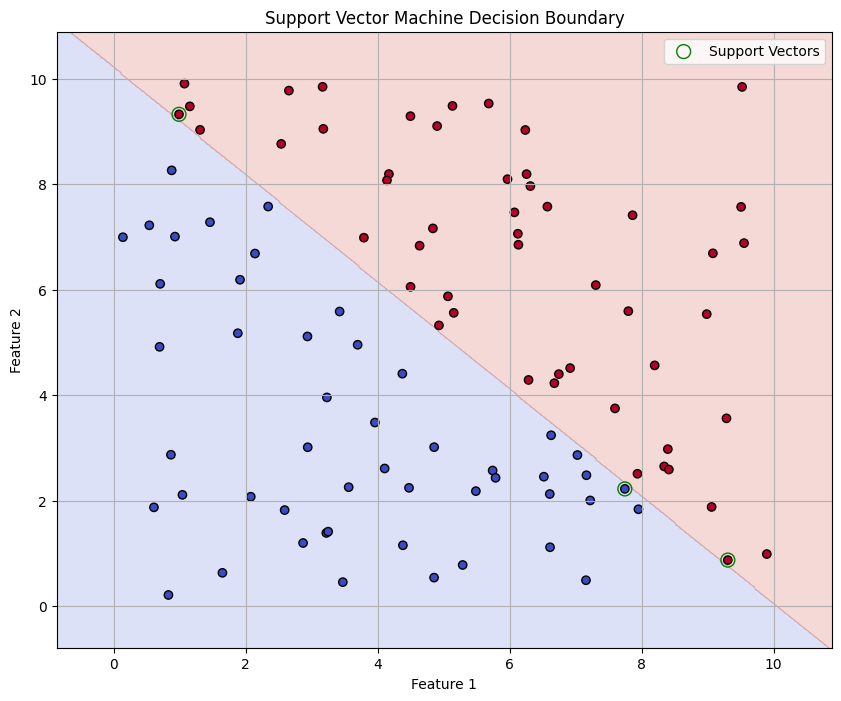

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# 1. Re-create the synthetic dataset
X = np.random.rand(100, 2) * 10
y = (X[:, 0] + X[:, 1] > 10).astype(int)

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Re-train the model on the full dataset for better visualization
# Using the full dataset (X, y) to train the model for visualization purposes,
# as it gives a more complete picture of the decision boundary.
svc_model = SVC(kernel='linear', C=100)
svc_model.fit(X, y)

# 4. Create a mesh grid to plot the decision boundary
h = .02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 5. Predict the class for each point in the mesh grid
Z = svc_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 6. Plot the decision boundary and the data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.20)

# Plot the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

# Plot the support vectors
plt.scatter(svc_model.support_vectors_[:, 0], svc_model.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='green', label='Support Vectors')

# Add labels, title, and legend
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Support Vector Machine Decision Boundary')
plt.legend()
plt.grid(True)
plt.savefig('svc_decision_boundary.png')

print("The visualization has been saved to svc_decision_boundary.png")

## Problem on Non-Linear Decision Boundary

 We now investigate a non-linear
decision boundary.
**(a)** Sketch the curve
$$
(1 + X_1)^2 + (2 - X_2)^2 = 4.
$$

**(b)** On your sketch, indicate the regions:
- Points satisfying  
  $$
  (1 + X_1)^2 + (2 - X_2)^2 > 4
  $$
- Points satisfying  
  $$
  (1 + X_1)^2 + (2 - X_2)^2 \le 4.
  $$

**(c)** A classifier assigns an observation to the **blue** class if  
$$
(1 + X_1)^2 + (2 - X_2)^2 > 4,
$$
and to the **red** class otherwise.

Determine the class for the following points:

- $(0, 0)$  
- $(-1, 1)$  
- $(2, 2)$  
- $(3, 8)$  

**(d)** Show that although the decision boundary in (c) is nonlinear in terms of $X_1$ and $X_2$, it becomes linear when expressed using the features  
$$
X_1,\quad X_1^2,\quad X_2,\quad X_2^2.
$$


---

## (a) Sketch the curve

The curve  
\[
(1 + X_1)^2 + (2 - X_2)^2 = 4
\]  
is a **circle** of radius \(2\) centered at \((-1, 2)\).

The following Python cell draws the sketch.

---

## (b) Indicate inside/outside of the curve

The inequality  
\[
(1 + X_1)^2 + (2 - X_2)^2 > 4  
\]
corresponds to **points outside the circle**, while  
\[
(1 + X_1)^2 + (2 - X_2)^2 \le 4  
\]
corresponds to **points inside or on the circle**.

The plot below shades inside/outside.


---

## (c) Classify points

Classifier rule:  
- **Blue class** if \((1 + X_1)^2 + (2 - X_2)^2 > 4\) (outside)  
- **Red class** otherwise (inside or on boundary)

We classify the points:
- \((0, 0)\)
- \((-1, 1)\)
- \((2, 2)\)
- \((3, 8)\)

---

## (d) Linear in transformed features

Although  
\[
(1 + X_1)^2 + (2 - X_2)^2 = 4
\]  
is **non-linear** in \(X_1, X_2\), expanding gives

\[
(X_1^2 + 2X_1 + 1) + (X_2^2 - 4X_2 + 4) = 4,
\]

which simplifies to

\[
X_1^2 + X_2^2 + 2X_1 - 4X_2 + 1 = 0.
\]

This is **linear in the variables**  
\[
X_1,\; X_2,\; X_1^2,\; X_2^2.
\]

Thus if we define transformed features:  
\[
Z_1 = X_1, \quad  
Z_2 = X_2, \quad  
Z_3 = X_1^2, \quad  
Z_4 = X_2^2,
\]
then the boundary is linear in \((Z_1, Z_2, Z_3, Z_4)\).

---



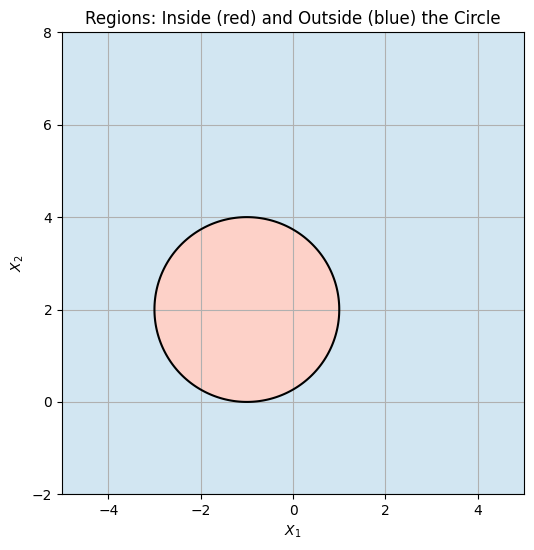

In [13]:
# grid to shade regions
x1_vals = np.linspace(-5, 5, 400)
x2_vals = np.linspace(-2, 8, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

expr = (1 + X1)**2 + (2 - X2)**2

plt.figure(figsize=(6,6))
plt.contour(X1, X2, expr, levels=[4], colors='black')
plt.contourf(X1, X2, expr, levels=[0,4], alpha=0.3, cmap="Reds")   # inside
plt.contourf(X1, X2, expr, levels=[4,200], alpha=0.3, cmap="Blues") # outside

plt.title("Regions: Inside (red) and Outside (blue) the Circle")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.gca().set_aspect('equal', 'box')
plt.grid(True)
plt.show()


### SVM: Linear vs. RBF Kernel

#### 1. Problem and Loss Function
We classify a **non-linear dataset** (two concentric circles).  
The SVM optimization problem:

- **Primal objective**
  $$
  \min_{\mathbf{w}, b, \xi} \ \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_i \xi_i
  $$
- **Constraints**
  $$
  y_i(\mathbf{w}^\top \phi(\mathbf{x}_i) + b) \ge 1 - \xi_i, \qquad \xi_i \ge 0
  $$

- Linear kernel uses  
  $\phi(\mathbf{x}) = \mathbf{x}$  
- RBF kernel uses  
  $$
  K(\mathbf{x},\mathbf{x}') = \exp\!\left(-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2\right)
  $$

The dataset is **not linearly separable**, so the linear SVM has limited expressive power.

---

#### 2. Weight Training (Model Fitting)
- SVM learns parameters \(\mathbf{w}\) and \(b\) (or dual coefficients \(\alpha_i\)) by solving the margin-maximization problem.
- In the RBF case, the classifier is:
  $$
  f(\mathbf{x}) = \sum_i \alpha_i y_i K(\mathbf{x}_i,\mathbf{x}) + b
  $$
- Only support vectors have non-zero \(\alpha_i\).

Training steps in code:
- Fit linear SVM: `SVC(kernel='linear')`
- Fit kernel SVM: `SVC(kernel='rbf')`

---

#### 3.  Objective
We compare **decision boundaries** produced by:
- A **linear kernel**, which can only produce **straight-line** boundaries.
- An **RBF kernel**, which can produce **curved / non-linear** boundaries.

Hyperparameters varied:
- Kernel type: `linear` vs. `rbf`
- RBF smoothness: controlled by  
  $\gamma = 1000$ (very high → highly flexible boundary)


---

#### 4. Remarks
- Linear SVM fails because the data are **not linearly separable** in \(\mathbb{R}^2\).
- RBF transforms the space implicitly using the kernel trick, enabling a **circular** decision boundary.
- Very large `gamma` yields extremely local behavior; can overfit.
- With appropriate kernels, SVM can separate non-linear data without explicitly constructing new features.
- Accuracy comparison highlights the importance of choosing a kernel that matches data geometry.



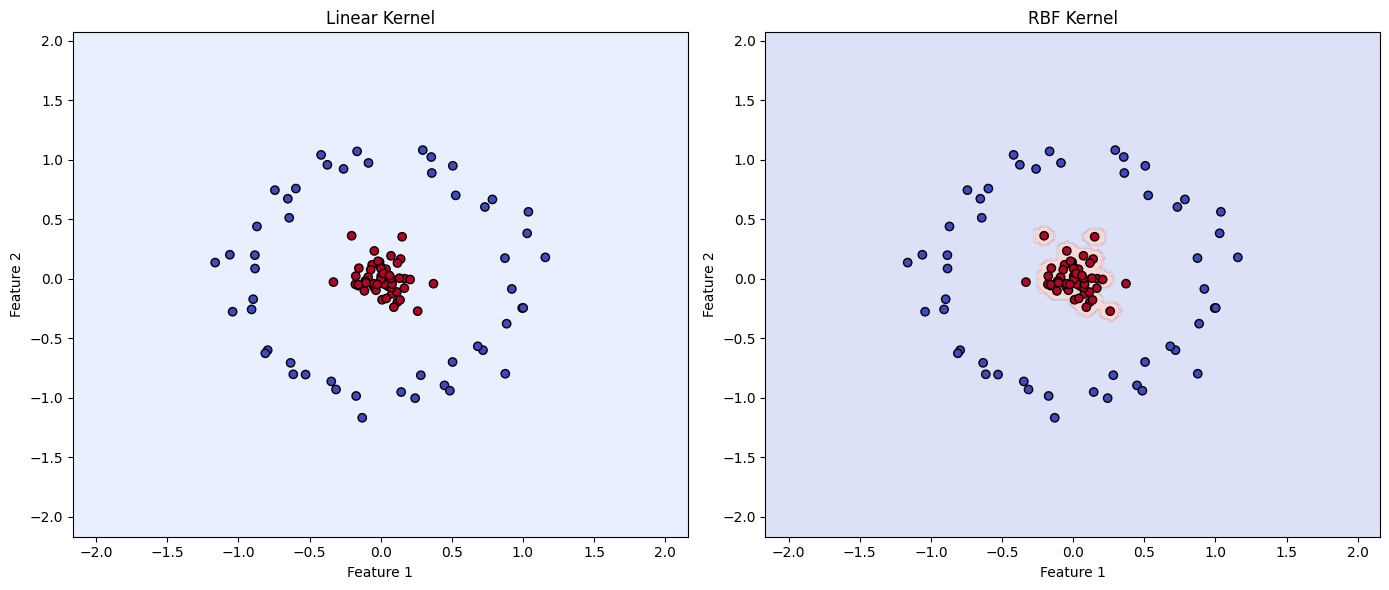

Accuracy with Linear Kernel: 0.33
Accuracy with RBF Kernel: 0.93


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# 1. Create a non-linear dataset (concentric circles)
X, y = make_circles(n_samples=100, factor=.1, noise=.1, random_state=42)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and train SVM with a Linear Kernel
linear_svc = SVC(kernel='linear', C=1.0)
linear_svc.fit(X_train, y_train)

# 4. Initialize and train SVM with an RBF Kernel
rbf_svc = SVC(kernel='rbf', C=1.0, gamma=1000)
rbf_svc.fit(X_train, y_train)

# 5. Create a mesh grid for plotting the decision boundaries
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 6. Make predictions on the mesh grid for both models
Z_linear = linear_svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)

Z_rbf = rbf_svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

# 7. Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear Kernel
ax1.set_title('Linear Kernel')
ax1.contourf(xx, yy, Z_linear, cmap=plt.cm.coolwarm, alpha=0.2)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')

# Plot for RBF Kernel
ax2.set_title('RBF Kernel')
ax2.contourf(xx, yy, Z_rbf, cmap=plt.cm.coolwarm, alpha=0.2)
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Print the model accuracies
print(f"Accuracy with Linear Kernel: {linear_svc.score(X_test, y_test):.2f}")
print(f"Accuracy with RBF Kernel: {rbf_svc.score(X_test, y_test):.2f}")

### Effect of Gamma in RBF Kernel SVM

#### 1. Problem and Loss Function
We classify a **non-linear dataset** consisting of two concentric circles.

The SVM with RBF kernel minimizes:

- **Objective**
  $$
  \min_{\alpha}\
  \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j K(\mathbf{x}_i,\mathbf{x}_j)
  - \sum_i \alpha_i
  $$
  subject to  
  $$
  0 \le \alpha_i \le C, \qquad \sum_i \alpha_i y_i = 0.
  $$

- **Kernel Function**
  $$
  K(\mathbf{x},\mathbf{x}') = \exp\!\left(-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2\right)
  $$

The RBF kernel defines similarity; the parameter **γ (gamma)** controls the rate at which similarity decays.

---

#### 2. Weight Training (Model Fitting)
Training steps performed for each γ:

1. Solve the SVM dual optimization with the RBF kernel.
2. Obtain dual coefficients \(\alpha_i\) corresponding to support vectors.
3. Evaluate the classifier:
   $$
   f(\mathbf{x}) = \sum_{i \in SV} \alpha_i y_i K(\mathbf{x}_i,\mathbf{x}) + b
   $$

Each γ produces a different **effective feature space**, altering the decision boundary.

---

#### 3. Objective of the Experiment — What We Vary?
We vary:

- **Gamma values:**  
  \[
  \gamma \in \{0.1,\ 1,\ 10,\ 100\}
  \]

Gamma controls the *complexity* of the boundary:

- Small γ → broad similarity → **smooth, simple boundary**
- Moderate γ → reasonable curvature
- Large γ → narrow similarity → **highly flexible, potentially overfitted boundary**

Goal:
- Visualize how γ affects the **decision boundary geometry**
- Compare test accuracy for each γ
- Understand the trade-off between smoothness and overfitting

---

#### 4. Remarks
- Low γ may underfit: boundary too smooth to capture circular structure.
- High γ may overfit: boundary becomes extremely wiggly.
- Moderate γ typically yields best generalization.
- RBF kernel implicitly maps points into infinite-dimensional space, but γ determines **how localized** each support vector's influence is.
- Decision boundary becomes more complex with increasing γ


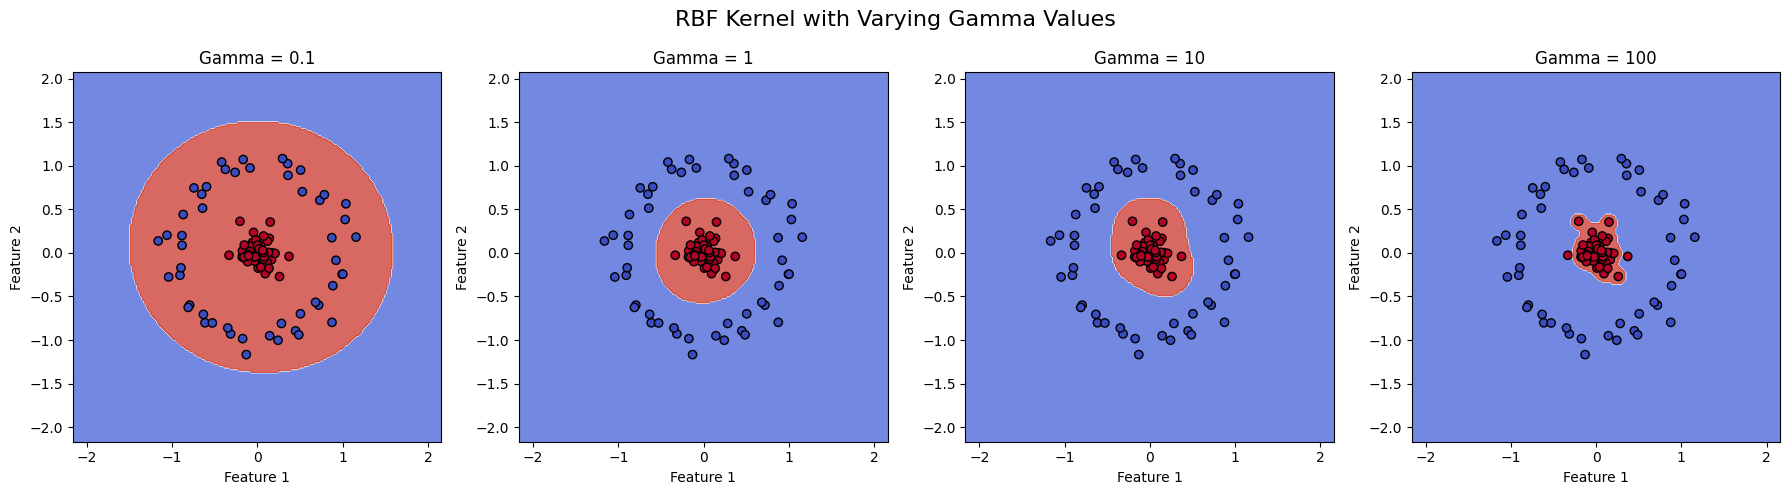

Accuracies with varying Gamma values:
Gamma = 0.1: Accuracy = 0.33
Gamma = 1: Accuracy = 1.00
Gamma = 10: Accuracy = 1.00
Gamma = 100: Accuracy = 0.93


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# 1. Create a non-linear dataset (concentric circles)
X, y = make_circles(n_samples=100, factor=.1, noise=.1, random_state=42)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Define a list of gamma values to test
gamma_values = [0.1, 1, 10, 100]

# 4. Create a figure to plot the results
fig, axes = plt.subplots(1, len(gamma_values), figsize=(18, 5))
fig.suptitle('RBF Kernel with Varying Gamma Values', fontsize=16)

# 5. Loop through each gamma value
for i, gamma in enumerate(gamma_values):
    # Initialize and train SVM with RBF Kernel
    rbf_svc = SVC(kernel='rbf', C=1.0, gamma=gamma)
    rbf_svc.fit(X_train, y_train)

    # Create a mesh grid for plotting the decision boundaries
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Make predictions on the mesh grid
    Z = rbf_svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary and data points on the subplot
    ax = axes[i]
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(f'Gamma = {gamma}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Print the accuracies for each gamma value
print("Accuracies with varying Gamma values:")
for gamma in gamma_values:
    rbf_svc = SVC(kernel='rbf', C=1.0, gamma=gamma)
    rbf_svc.fit(X_train, y_train)
    accuracy = rbf_svc.score(X_test, y_test)
    print(f"Gamma = {gamma}: Accuracy = {accuracy:.2f}")

### Polynomial and RBF Kernel Behavior on Two-Moons Dataset

#### 1. Problem and Loss Function
We classify the **two-moons dataset**, a standard non-linear benchmark.

SVM solves the margin-maximization problem:

- **Dual objective**
  $$
  \max_{\alpha}
  \sum_i \alpha_i
  - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j K(\mathbf{x}_i,\mathbf{x}_j)
  $$
  subject to  
  $$
  0 \le \alpha_i \le C,\qquad
  \sum_i \alpha_i y_i = 0.
  $$

Two kernel types appear in this experiment:

1. **Polynomial kernel (evaluated in accuracy section only):**  
   $$
   K(\mathbf{x},\mathbf{x}') = (\gamma\, \mathbf{x}^\top \mathbf{x}' + r)^d
   $$

2. **RBF kernel (visualization section):**  
   $$
   K(\mathbf{x},\mathbf{x}') = \exp\!\left(-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2\right)
   $$

---

#### 2. Weight Training (Model Fitting)
Training for each model involves:

1. Solving the dual optimization using the chosen kernel.
2. Obtaining non-zero dual coefficients \(\alpha_i\) corresponding to support vectors.
3. Forming the classifier:
   $$
   f(\mathbf{x}) = \sum_{i\in SV} \alpha_i y_i K(\mathbf{x}_i,\mathbf{x}) + b.
   $$

The learned boundary depends on:
- Kernel type (polynomial vs. RBF)
- Kernel parameters (degree or gamma)

---

#### 3. Objective
This experiment has **two components**:

**A. Visualization**  
- We fix the kernel to **RBF** and vary:
  \[
  \gamma \in \{0.1,\ 1,\ 10,\ 100\}.
  \]
- Goal: observe how γ alters decision-boundary curvature.

**B. Accuracy Evaluation**  
- We switch to the **polynomial kernel** and vary the **degree**:
  \[
  d \in \{7,\ 10,\ 12,\ 15\}.
  \]
- Goal: observe how increasing polynomial degree affects generalization.

**Interpretation:**

- Larger γ → more localized influence → highly flexible boundaries.  
- Larger polynomial degree → more complex feature space → potentially overfitted classifier.

---

#### 4. Remarks
- The two-moons dataset requires **non-linear separation**; linear SVMs cannot model this geometry.
- RBF kernel provides smooth boundaries at small γ and highly curved boundaries at large γ.
- Polynomial kernel complexity grows rapidly with degree; high degrees risk fitting noise instead of structure.
- RBF visualization and polynomial accuracy evaluation together show how kernel choice and parameter scaling affect:
  - Margin geometry  
  - Smoothness vs. complexity  
  - Final classification accuracy  



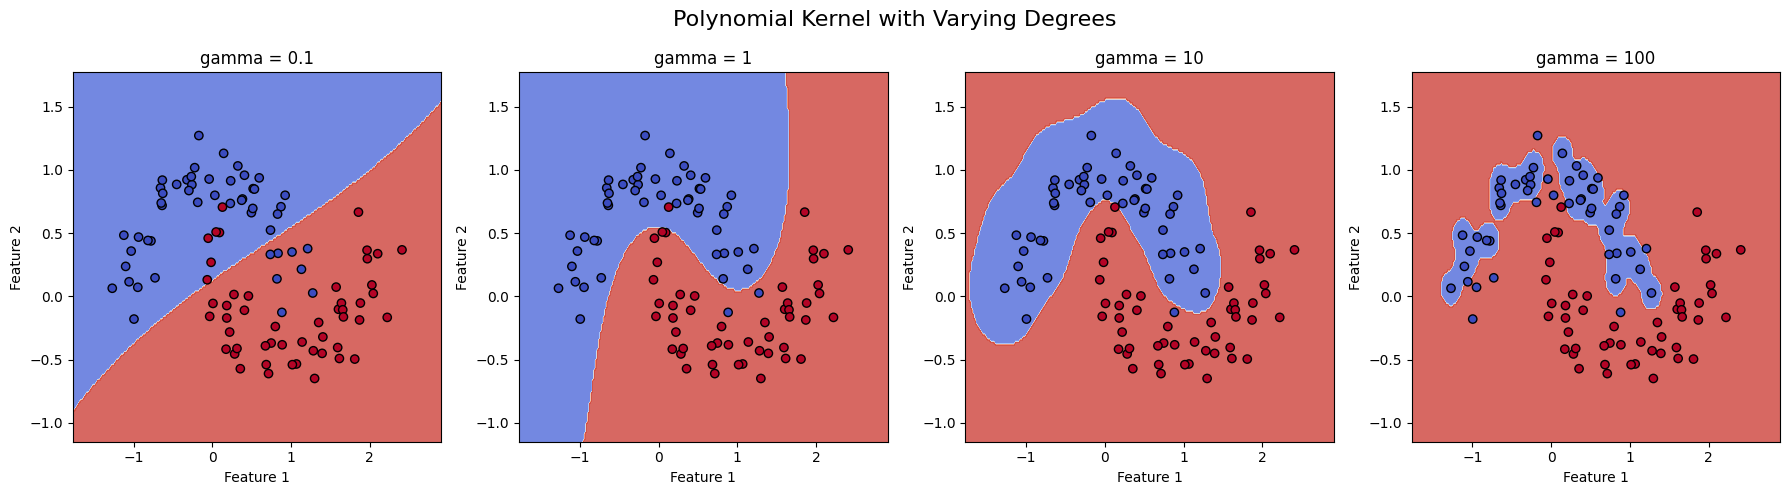

Accuracies with varying Polynomial degrees:
Degree = 7: Accuracy = 0.87
Degree = 10: Accuracy = 0.80
Degree = 12: Accuracy = 0.80
Degree = 15: Accuracy = 0.80


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 1. Create a non-linear dataset (two moons)
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Define a list of polynomial degrees to test
degrees = [7, 10, 12, 15]
gamma_values = [0.1, 1, 10, 100]

# 4. Create a figure to plot the results
fig, axes = plt.subplots(1, len(degrees), figsize=(18, 5))
fig.suptitle('Polynomial Kernel with Varying Degrees', fontsize=16)

# 5. Loop through each degree value
for i, gamma in enumerate(gamma_values):
    # Initialize and train SVM with Polynomial Kernel
   # poly_svc = SVC(kernel='poly', C=1.0, degree=degree, gamma='auto')
   # poly_svc.fit(X_train, y_train)
    poly_svc = SVC(kernel='rbf', C=1.0, gamma=gamma)
    poly_svc.fit(X_train, y_train)

    # Create a mesh grid for plotting the decision boundaries
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Make predictions on the mesh grid
    Z = poly_svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary and data points on the subplot
    ax = axes[i]
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(f'gamma = {gamma}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Print the accuracies for each degree value
print("Accuracies with varying Polynomial degrees:")
for degree in degrees:
    poly_svc = SVC(kernel='poly', C=1.0, degree=degree, gamma='auto')
    poly_svc.fit(X_train, y_train)
    accuracy = poly_svc.score(X_test, y_test)
    print(f"Degree = {degree}: Accuracy = {accuracy:.2f}")


## 3) SVM for Regression (SVR)
We'll fit an **SVR** with an RBF kernel to noisy, nonlinear 1D data, and compare fits for different hyperparameters.

 In classification:

* Boundary divides classes

* Distance from boundary determines support vectors

In regression (SVR):

* We fit a curve

* We allow an ε-insensitive margin (tube) around the function

* Points inside the tube don’t matter; points outside the tube become support vectors


Advantages:


- SVR smooths noisy data
- SVR with RBF kernel approximates nonlinear functions
- SVR does not try to hit every point — it creates a margin around the true function
- Extra noisy points do not pull the curve aggressively (if ε is reasonable)

####  Problem and Loss Function

Goal: approximate the nonlinear mapping
\[
y \approx f(x) = \sin(x)
\]
from noisy observations.

Support Vector Regression (SVR) with RBF kernel solves:

- **Objective**
  \[
  \min_{\mathbf{w}, b, \xi_i, \xi_i^*}
  \frac{1}{2}\|\mathbf{w}\|^2
  + C \sum_i (\xi_i + \xi_i^*)
  \]
- **Constraints**
  \[
  \begin{aligned}
  y_i - (\mathbf{w}^\top \phi(\mathbf{x}_i) + b) &\le \varepsilon + \xi_i, \\
  (\mathbf{w}^\top \phi(\mathbf{x}_i) + b) - y_i &\le \varepsilon + \xi_i^*, \\
  \xi_i, \xi_i^* &\ge 0.
  \end{aligned}
  \]

- **Kernel (RBF)**
  \[
  K(\mathbf{x},\mathbf{x}') = \exp\!\left(-\gamma \lVert\mathbf{x}-\mathbf{x}'\rVert^2\right)
  \]

Loss is **ε-insensitive**: errors smaller than \(\varepsilon\) are ignored, larger errors penalized linearly via \(C\).

---

#### Model Training and Parameters

The helper function `fit_svr_and_predict`:

1. Standardizes input \(x\) using `StandardScaler`.
2. Fits an `SVR` model with specified:
   - `kernel` (here: `"rbf"`)
   - `C` (regularization strength)
   - `gamma` (RBF kernel width)
   - `epsilon` (ε-insensitive tube width)
   - `degree` (only used for polynomial kernels)

The prediction function:
\[
\hat{f}(x) = \sum_{i \in SV} (\alpha_i - \alpha_i^*) K(\mathbf{x}_i, x) + b
\]

Model evaluation on test data:
- Mean Squared Error (MSE):
  \[
  \text{MSE} = \frac{1}{n} \sum_i (y_i - \hat{y}_i)^2
  \]
- Coefficient of determination:
  \[
  R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
  \]

---

#### Objective

- Fit a **baseline RBF SVR** with:
  - \(C = 1.0\)
  - \(\gamma = 1.0\)
  - \(\varepsilon = 0.1\)
- Compare:
  - True function \( \sin(x) \)
  - Noisy training and test points
  - Baseline SVR prediction curve

Learner tasks:
- Inspect alignment between `SVR` curve and `\sin(x)`.
- Note where prediction is biased due to noise or tube width \(\varepsilon\).

Potential extensions (not coded here, but suggested):
- Vary `C` (under/over-regularization).
- Vary `gamma` (smooth vs. highly wiggly curves).
- Vary `epsilon` (tight vs. wide error tolerance).

---

#### 4. Remarks

- SVR with RBF kernel can approximate smooth nonlinear functions effectively.
- Standardization via `StandardScaler` is critical for stable kernel behavior.
- Trade-offs:
  - Larger \(C\): lower bias, higher variance (risk of overfitting).
  - Larger \(\gamma\): highly localized kernels, more complex curves.
  - Larger \(\varepsilon\): fewer support vectors, smoother and more tolerant fit.
- MSE and \(R^2\) quantify how well the model generalizes to unseen data.




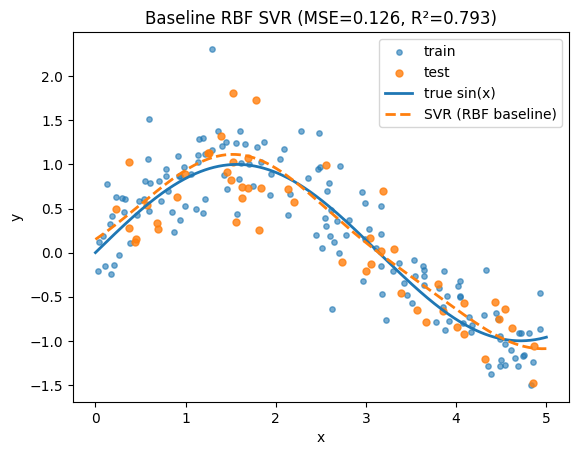

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Synthetic nonlinear regression data
rng = np.random.RandomState(42)
Xr = np.sort(5 * rng.rand(200, 1), axis=0)
yr = np.sin(Xr).ravel() + 0.35 * rng.randn(200)

Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.25, random_state=42)

# dense grid for plotting
X_dense = np.linspace(0, 5, 400).reshape(-1, 1)
y_true = np.sin(X_dense).ravel()
def fit_svr_and_predict(kernel="rbf", C=1.0, gamma=1.0, epsilon=0.1, degree=2, label=None):
    svr = Pipeline([
        ('sc', StandardScaler()),
        ('svr', SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon, degree=degree))
    ])
    svr.fit(Xtr, ytr)
    y_hat_dense = svr.predict(X_dense)
    y_hat_test  = svr.predict(Xte)

    mse = mean_squared_error(yte, y_hat_test)
    r2  = r2_score(yte, y_hat_test)

    if label is None:
        label = f"{kernel}, C={C}, γ={gamma}, ε={epsilon}"
    return svr, y_hat_dense, mse, r2, label
svr_base, y_hat_base, mse_base, r2_base, _ = fit_svr_and_predict(
    kernel="rbf", C=1.0, gamma=1.0, epsilon=0.1
)

plt.figure()
plt.scatter(Xtr, ytr, s=15, alpha=0.6, label='train')
plt.scatter(Xte, yte, s=25, alpha=0.8, label='test')
plt.plot(X_dense, y_true, linewidth=2, label='true sin(x)')
plt.plot(X_dense, y_hat_base, linewidth=2, linestyle='--', label='SVR (RBF baseline)')
plt.legend()
plt.title(f"Baseline RBF SVR (MSE={mse_base:.3f}, R²={r2_base:.3f})")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


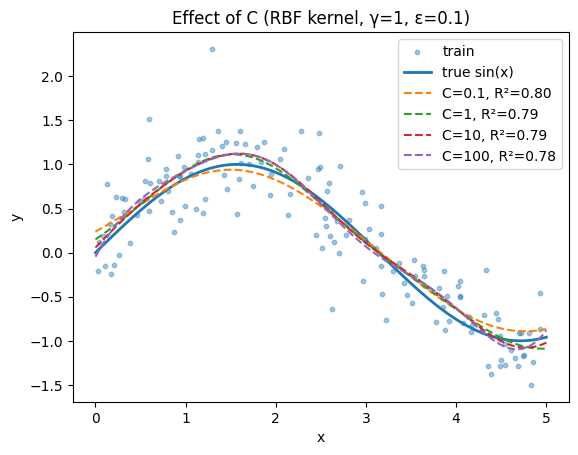

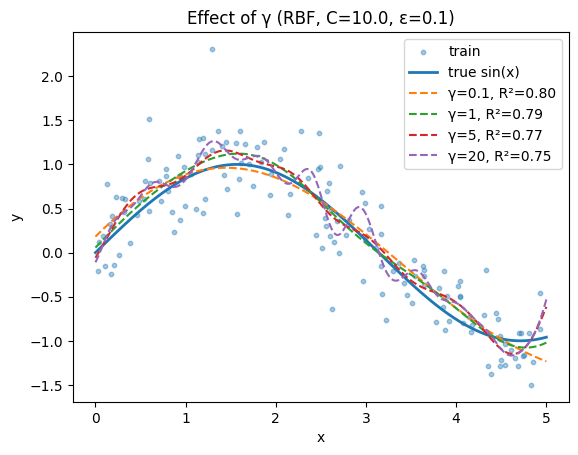

In [18]:
Cs = [0.1, 1, 10, 100]
plt.figure()
plt.scatter(Xtr, ytr, s=10, alpha=0.4, label='train')
plt.plot(X_dense, y_true, linewidth=2, label='true sin(x)')

for C in Cs:
    _, y_hat, mse, r2, _ = fit_svr_and_predict(kernel="rbf", C=C, gamma=1.0, epsilon=0.1)
    plt.plot(X_dense, y_hat, linestyle='--', label=f"C={C}, R²={r2:.2f}")

plt.legend()
plt.title("Effect of C (RBF kernel, γ=1, ε=0.1)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


gammas = [0.1, 1, 5, 20]
C_fixed = 10.0

plt.figure()
plt.scatter(Xtr, ytr, s=10, alpha=0.4, label='train')
plt.plot(X_dense, y_true, linewidth=2, label='true sin(x)')

for g in gammas:
    _, y_hat, mse, r2, _ = fit_svr_and_predict(kernel="rbf", C=C_fixed, gamma=g, epsilon=0.1)
    plt.plot(X_dense, y_hat, linestyle='--', label=f"γ={g}, R²={r2:.2f}")

plt.legend()
plt.title(f"Effect of γ (RBF, C={C_fixed}, ε=0.1)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()



#### Objective
We vary the **ε (epsilon)** parameter in SVR and visualize:

1. How the regression curve changes.
2. How the **number and location of support vectors** change.
3. The trade-off between smoothness and data fidelity.

This is done while keeping `C` and `gamma` fixed.

---

#### Role of ε in SVR (ε-Insensitive Tube)

The SVR loss uses an **ε-insensitive region**:

- Errors **≤ ε** are *ignored* (no penalty).  
- Errors **> ε** are penalized linearly via slack variables.

Thus **ε controls how much deviation from the target is tolerated** without affecting the model.

Effect of ε:
- **Small ε** → tight tube → many points outside tube → many support vectors → more complex fit.
- **Large ε** → wide tube → fewer points outside tube → fewer support vectors → smoother fit.

Formally, support vectors satisfy:
\[
|y_i - f(x_i)| \ge \varepsilon.
\]

---
####  Remarks

- ε primarily controls **model sparsity**: larger ε → fewer support vectors.  
- It also indirectly controls **smoothness**: wider ε → smoother, simpler function.  
- Unlike `C` (which controls penalty strength), `ε` controls **when** penalties begin.  
- In practice, ε is tuned together with C and γ.


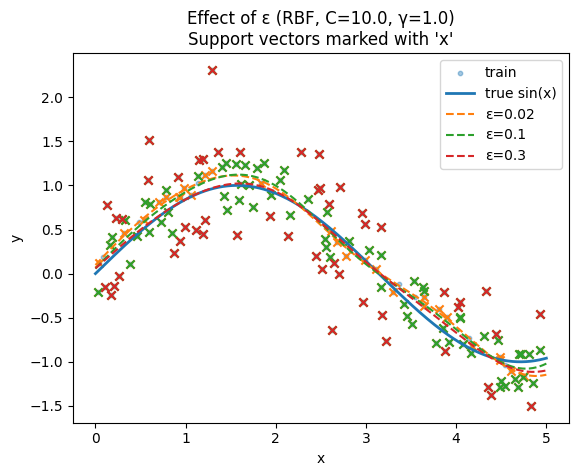

In [19]:
def plot_epsilon_effect(epsilons, C=10.0, gamma=1.0):
    plt.figure()
    plt.scatter(Xtr, ytr, s=10, alpha=0.4, label='train')
    plt.plot(X_dense, y_true, linewidth=2, label='true sin(x)')

    for eps in epsilons:
        svr = SVR(kernel="rbf", C=C, gamma=gamma, epsilon=eps)
        pipe = Pipeline([('sc', StandardScaler()), ('svr', svr)])
        pipe.fit(Xtr, ytr)
        y_hat = pipe.predict(X_dense)

        # Extract back support vectors (tricky but doable from raw SVR)
        svr_raw = pipe.named_steps['svr']
        sv_indices = svr_raw.support_
        X_sv = Xtr[sv_indices]
        y_sv = ytr[sv_indices]

        plt.plot(X_dense, y_hat, linestyle='--', label=f"ε={eps}")
        # Mark support vectors on the training set
        plt.scatter(X_sv, y_sv, s=35, marker='x')

    plt.legend()
    plt.title(f"Effect of ε (RBF, C={C}, γ={gamma})\nSupport vectors marked with 'x'")
    plt.xlabel("x"); plt.ylabel("y")
    plt.show()

plot_epsilon_effect([0.02, 0.1, 0.3], C=10.0, gamma=1.0)


This experiment compares two SVR kernels—RBF and quadratic polynomial—under identical hyperparameters.  
Both models attempt to approximate the nonlinear function \( \sin(x) \), but their feature spaces differ.  
RBF typically captures smooth nonlinear patterns more effectively, while a degree-2 polynomial has limited flexibility.  
The plotted curves and R² scores show how kernel choice directly affects approximation quality.


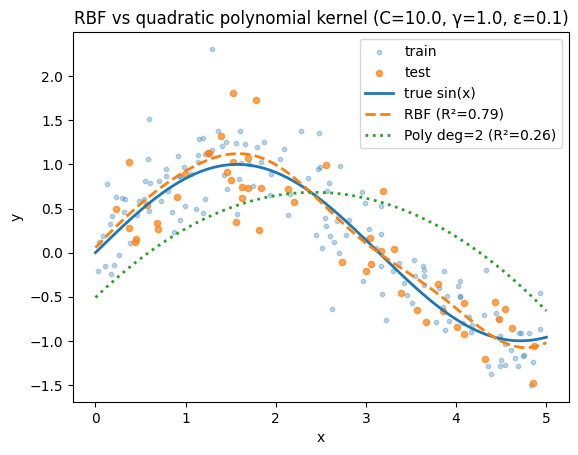

In [20]:
C_demo = 10.0
gamma_demo = 1.0
epsilon_demo = 0.1

# RBF
svr_rbf, y_hat_rbf, mse_rbf, r2_rbf, _ = fit_svr_and_predict(
    kernel="rbf", C=C_demo, gamma=gamma_demo, epsilon=epsilon_demo
)

# Quadratic polynomial (degree=2)
svr_poly2, y_hat_poly2, mse_poly2, r2_poly2, _ = fit_svr_and_predict(
    kernel="poly", C=C_demo, gamma=gamma_demo, epsilon=epsilon_demo, degree=2
)

plt.figure()
plt.scatter(Xtr, ytr, s=10, alpha=0.3, label='train')
plt.scatter(Xte, yte, s=20, alpha=0.7, label='test')
plt.plot(X_dense, y_true, linewidth=2, label='true sin(x)')

plt.plot(X_dense, y_hat_rbf, linestyle='--', linewidth=2,
         label=f"RBF (R²={r2_rbf:.2f})")
plt.plot(X_dense, y_hat_poly2, linestyle=':', linewidth=2,
         label=f"Poly deg=2 (R²={r2_poly2:.2f})")

plt.legend()
plt.title(f"RBF vs quadratic polynomial kernel (C={C_demo}, γ={gamma_demo}, ε={epsilon_demo})")
plt.xlabel("x"); plt.ylabel("y")
plt.show()



## 4) SVMs for Text & Sets

We'll look at two data types where kernels shine beyond plain vectors:

1. **Text** (bag-of-words / TF–IDF): in high-dimensional sparse spaces, **linear SVM** is strong and fast.  
2. **Sets**: we can use a **custom kernel** such as **Jaccard** and feed a precomputed kernel matrix to `SVC`.

### 1 Text Classification with Linear SVM (TF–IDF + LinearSVC)

#### Problem Setup
We classify short review sentences into **positive** (1) or **negative** (0) sentiment.  
Raw text is converted into numerical features using **TF–IDF vectors**, enabling a linear SVM classifier to operate on word- and phrase-based features.

---

####  Representation and Model

**TF–IDF Encoding**
- Converts text into weighted features based on term frequency and inverse document frequency.
- Supports **n-grams**; here `(1,2)` includes unigrams and bigrams.
- `min_df` removes rare terms.

**LinearSVC (linear kernel SVM)**
- Optimizes the hinge loss with L2 regularization.
- Directly supports multi-class classification (OvR) if needed.
- Parameter **C** controls margin softness:
  - Small \(C\): stronger regularization → smoother boundary.
  - Large \(C\): weaker regularization → risk of overfitting.

---

####  Objective
1. Train a baseline LinearSVC using TF–IDF features.  
2. Evaluate training and test accuracy.  
3. Study the **effect of varying C** on performance.  
4. Produce predictions for custom text inputs.

The goal is to understand:
- How regularization affects generalization.
- How n-gram features influence classification quality.
- How linear SVM behaves on sparse, high-dimensional text data.

---

####  Remarks
- Text data is typically **linearly separable** in TF–IDF space, making LinearSVC highly effective.
- Larger C often improves fit on small datasets—but may reduce generalization.
- Bigram features (1,2-grams) help capture short phrases such as “not good”, which are sentiment-relevant.
- The prediction function uses the same TF–IDF vectorizer to ensure consistent feature mapping.



In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


# ---- Toy dataset: tiny movie reviews
texts = [
  "I love this movie, it is fantastic and fun",
  "What a great film, brilliant acting",
  "Terrible plot and boring scenes",
  "Horrible waste of time, very bad",
  "Absolutely wonderful, a delightful story",
  "Awful experience, I hated it",
  "Outstanding direction and superb cast",
  "Bad script with poor dialogue",
  "A charming and heartwarming tale",
  "Disappointing and dull from start to finish"
]

labels = np.array([1,1,0,0,1,0,1,0,1,0])  # 1=positive, 0=negative

# Fixed train/test split so results don't jump around
Xtr_text, Xte_text, ytr_text, yte_text = train_test_split(
  texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print("Train size:", len(Xtr_text), " Test size:", len(Xte_text))



Train size: 8  Test size: 2


In [22]:
def train_and_eval(C=1.0, ngram_range=(1,1), min_df=1):
    # Vectorizer
    tfidf = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df)
    Xtr_vec = tfidf.fit_transform(Xtr_text)
    Xte_vec = tfidf.transform(Xte_text)

    # Linear SVM
    clf = LinearSVC(C=C)
    clf.fit(Xtr_vec, ytr_text)

    # Accuracy on train and test
    ytr_pred = clf.predict(Xtr_vec)
    yte_pred = clf.predict(Xte_vec)

    train_acc = accuracy_score(ytr_text, ytr_pred)
    test_acc = accuracy_score(yte_text, yte_pred)

    return train_acc, test_acc, tfidf, clf
train_acc, test_acc, tfidf, clf = train_and_eval(
    C=1.0,
    ngram_range=(1,2),
    min_df=1
)

print("Baseline with C=1.0, ngram_range=(1,2), min_df=1")
print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)
print()
print("Classification report on test set:")
yhat = clf.predict(tfidf.transform(Xte_text))
print(classification_report(yte_text, yhat))


Baseline with C=1.0, ngram_range=(1,2), min_df=1
Train accuracy: 1.0
Test accuracy: 0.5

Classification report on test set:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


C=  0.01  train=1.00  test=0.50
C=   0.1  train=1.00  test=0.50
C=     1  train=1.00  test=0.50
C=    10  train=1.00  test=1.00
C=   100  train=1.00  test=1.00


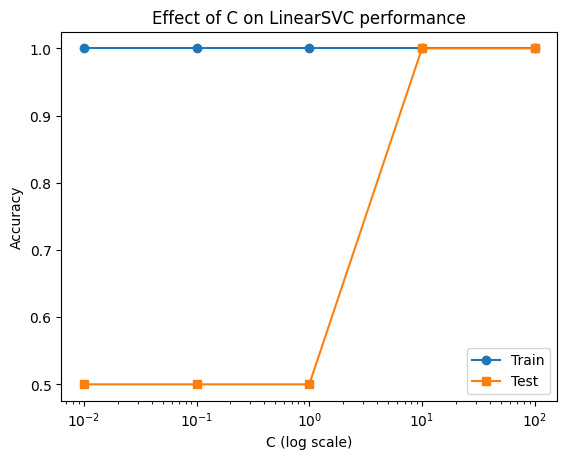

In [23]:
Cs = [0.01, 0.1, 1, 10, 100]
train_accs = []
test_accs = []

for C in Cs:
    tr_acc, te_acc, _, _ = train_and_eval(
        C=C,
        ngram_range=(1,2),
        min_df=1
    )
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f"C={C:6g}  train={tr_acc:.2f}  test={te_acc:.2f}")

plt.figure()
plt.plot(Cs, train_accs, marker='o', label="Train")
plt.plot(Cs, test_accs, marker='s', label="Test")
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of C on LinearSVC performance")
plt.legend()
plt.show()



In [24]:
def predict_sentiment(text):
    X = tfidf.transform([text])
    pred = clf.predict(X)[0]
    label = "positive" if pred == 1 else "negative"
    print(f"Text: {text}")
    print(f"Predicted sentiment: {label}")

# Example usages
predict_sentiment("This movie was absolutely wonderful and fun")
predict_sentiment("What a horrible and boring film")
predict_sentiment("The food here is bad")
predict_sentiment("The food here is not so bad")


Text: This movie was absolutely wonderful and fun
Predicted sentiment: positive
Text: What a horrible and boring film
Predicted sentiment: negative
Text: The food here is bad
Predicted sentiment: negative
Text: The food here is not so bad
Predicted sentiment: negative


### 2. SVM with Custom Jaccard Kernel on Sets

####  Problem Setup
We classify **baskets of discrete items** (subsets of a fixed universe) into two classes:
- Label 1: basket contains item `1` and at least one of `{5, 7}` (with small label noise).
- Label 0: otherwise.

Input objects are **sets**, not numeric vectors, so we construct a custom kernel.

---

####  Jaccard Kernel on Sets
For two baskets \(A\) and \(B\), the **Jaccard similarity** is:
$$
K(A,B) = \frac{|A \cap B|}{|A \cup B|}.
$$
Properties:
- Symmetric, values in \([0,1]\).
- Measures overlap relative to union size.
- Used as a **precomputed kernel** matrix:
  - \(K_{\text{train}}[i,j] = K(A_i, A_j)\)
  - \(K_{\text{test}}[i,j] = K(B_i, A_j)\)

---

####  SVM with Precomputed Kernel
We use `SVC(kernel="precomputed")`:
- SVM optimization operates **only on the kernel matrix** \(K\), not raw sets.
- Parameter **C** controls the soft-margin trade-off, as in standard SVM.
- The experiment:
  1. Builds Jaccard kernel matrices for train and test sets.
  2. Fits SVM on \(K_{\text{train}}\).
  3. Evaluates accuracy and classification report on the test set.
  4. Sweeps over different values of \(C\) to study regularization.

---

#### Interpretation and Remarks
- This example shows how SVMs can work with **non-vector data** (sets) via a suitable kernel.
- Jaccard kernel encodes **semantic similarity of item baskets** (shared items).
- The \(C\)-curve illustrates the usual pattern:
  - Small \(C\): underfitting (high bias).
  - Large \(C\): possible overfitting (low bias, high variance).
- `predict_basket` demonstrates prediction for new baskets by computing their kernel row against training baskets.



In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --- Jaccard kernel on sets ---
def jaccard_kernel_sets(X_sets_A, X_sets_B=None):
    # X_sets_A and X_sets_B are lists of python sets
    if X_sets_B is None:
        X_sets_B = X_sets_A
    K = np.zeros((len(X_sets_A), len(X_sets_B)))
    for i, A in enumerate(X_sets_A):
        for j, B in enumerate(X_sets_B):
            inter = len(A & B)
            union = len(A | B)
            K[i, j] = inter / union if union > 0 else 0.0
    return K

# --- Synthetic dataset: baskets of items ---
rng = np.random.RandomState(123)
universe = list(range(20))   # items 0..19

def sample_set():
    # random set size 3–8
    size = rng.randint(3, 9)
    return set(rng.choice(universe, size=size, replace=False))

X_sets = [sample_set() for _ in range(200)]

# Label rule: 1 if contains 1 and (5 or 7), else 0, plus a bit of noise
y_sets = []
for s in X_sets:
    label = 1 if (1 in s and (5 in s or 7 in s)) else 0
    # add ~8% label noise
    if rng.rand() < 0.08:
        label = 1 - label
    y_sets.append(label)
y_sets = np.array(y_sets)

Xtr_sets, Xte_sets, ytr_sets, yte_sets = train_test_split(
    X_sets, y_sets, test_size=0.3, random_state=42, stratify=y_sets
)

print("Train size:", len(Xtr_sets), " Test size:", len(Xte_sets))
print("Example basket + label:")
for i in range(3):
    print(Xtr_sets[i], "->", ytr_sets[i])


Train size: 140  Test size: 60
Example basket + label:
{np.int64(1), np.int64(4), np.int64(13), np.int64(16), np.int64(17)} -> 0
{np.int64(1), np.int64(4), np.int64(8), np.int64(9), np.int64(16), np.int64(17), np.int64(18), np.int64(19)} -> 0
{np.int64(1), np.int64(2), np.int64(8), np.int64(13), np.int64(15)} -> 0


In [26]:
# --- Kernel matrices ---
K_tr = jaccard_kernel_sets(Xtr_sets)
K_te = jaccard_kernel_sets(Xte_sets, Xtr_sets)

# --- Baseline SVM with precomputed kernel ---
C_baseline = 5.0
svc_sets = SVC(kernel='precomputed', C=C_baseline)
svc_sets.fit(K_tr, ytr_sets)
yhat_sets = svc_sets.predict(K_te)

print(f"Baseline with C={C_baseline}")
print("Train accuracy:", accuracy_score(ytr_sets, svc_sets.predict(K_tr)))
print("Test  accuracy:", accuracy_score(yte_sets, yhat_sets))
print("\nClassification report (test):")
print(classification_report(yte_sets, yhat_sets))


Baseline with C=5.0
Train accuracy: 1.0
Test  accuracy: 0.9

Classification report (test):
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        51
           1       0.80      0.44      0.57         9

    accuracy                           0.90        60
   macro avg       0.85      0.71      0.76        60
weighted avg       0.89      0.90      0.89        60



C=  0.01  train=0.850  test=0.850
C=   0.1  train=0.850  test=0.850
C=     1  train=0.886  test=0.850
C=     5  train=1.000  test=0.900
C=    10  train=1.000  test=0.917
C=    50  train=1.000  test=0.917
C=   100  train=1.000  test=0.917


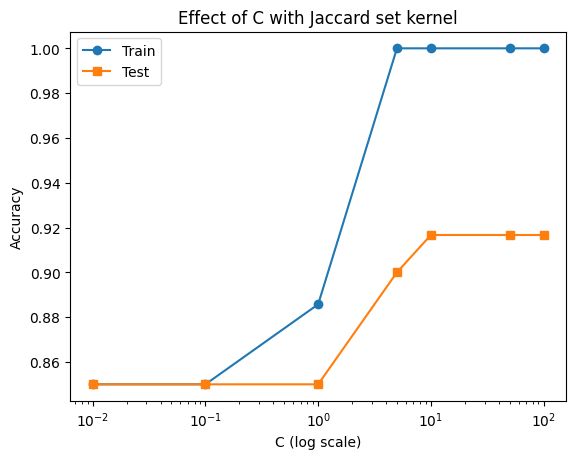

In [27]:
def train_eval_sets(C):
    K_tr = jaccard_kernel_sets(Xtr_sets)
    K_te = jaccard_kernel_sets(Xte_sets, Xtr_sets)

    clf = SVC(kernel='precomputed', C=C)
    clf.fit(K_tr, ytr_sets)

    ytr_pred = clf.predict(K_tr)
    yte_pred = clf.predict(K_te)

    tr_acc = accuracy_score(ytr_sets, ytr_pred)
    te_acc = accuracy_score(yte_sets, yte_pred)
    return tr_acc, te_acc

Cs = [0.01, 0.1, 1, 5, 10, 50, 100]
train_accs = []
test_accs = []

for C in Cs:
    tr, te = train_eval_sets(C)
    train_accs.append(tr)
    test_accs.append(te)
    print(f"C={C:6g}  train={tr:.3f}  test={te:.3f}")

plt.figure()
plt.plot(Cs, train_accs, marker='o', label="Train")
plt.plot(Cs, test_accs, marker='s', label="Test")
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of C with Jaccard set kernel")
plt.legend()
plt.show()


In [28]:
# Refit one model we’ll use for demo, say C=5
C_demo = 5.0
K_tr = jaccard_kernel_sets(Xtr_sets)
K_te = jaccard_kernel_sets(Xte_sets, Xtr_sets)
svc_demo = SVC(kernel='precomputed', C=C_demo)
svc_demo.fit(K_tr, ytr_sets)

print("Some test baskets and predictions:")
for i in range(5):
    basket = Xte_sets[i]
    true_label = yte_sets[i]
    pred_label = svc_demo.predict(K_te[i].reshape(1, -1))[0]
    print(f"Basket {i}: {sorted(basket)}")
    print(f"  True: {true_label},  Predicted: {pred_label}")


Some test baskets and predictions:
Basket 0: [np.int64(6), np.int64(10), np.int64(15)]
  True: 0,  Predicted: 0
Basket 1: [np.int64(6), np.int64(13), np.int64(16)]
  True: 1,  Predicted: 0
Basket 2: [np.int64(8), np.int64(9), np.int64(13), np.int64(14), np.int64(15), np.int64(19)]
  True: 0,  Predicted: 0
Basket 3: [np.int64(7), np.int64(9), np.int64(11), np.int64(12)]
  True: 0,  Predicted: 0
Basket 4: [np.int64(7), np.int64(12), np.int64(18)]
  True: 0,  Predicted: 0


In [29]:
def predict_basket(items):
    s = set(items)
    # compute kernel between this basket and all training baskets
    K_single = jaccard_kernel_sets([s], Xtr_sets)
    pred = svc_demo.predict(K_single)[0]
    print(f"Basket {sorted(items)} -> predicted label {pred}")

predict_basket([1, 5, 9])
predict_basket([1, 7, 2])
predict_basket([1, 3, 4])
predict_basket([2, 5, 7])
predict_basket([5,7,3])


Basket [1, 5, 9] -> predicted label 0
Basket [1, 2, 7] -> predicted label 1
Basket [1, 3, 4] -> predicted label 0
Basket [2, 5, 7] -> predicted label 0
Basket [3, 5, 7] -> predicted label 0



**Notes on custom kernels:**
- Any symmetric positive semi-definite \(K\) can be used as a kernel matrix with `SVC(kernel="precomputed")`.
- For structured data (strings, trees, graphs, sets), **domain-informed kernels** often outperform naive featurization.
- Try other options like **string kernels** (n-gram overlap), **histogram intersection**, or **RBF on learned embeddings**.



## 5) Reinforcement Learning: Q-learning

Goal. A robot must navigate from a start cell to a goal cell in a grid maze. Free cells are 0, walls are 1. The agent learns from trial and error using Q-learning.

We'll visualize learned behaviour, ε-greedy exploration, discounting, and learning rate.


Problem Setup

State: a grid cell (row, col).

Actions: up, down, left, right.

Transition: if an action hits a wall or boundary, the episode ends with a penalty (fire).

Rewards:

reward_goal for reaching the goal (episode ends),

reward_fire for hitting a wall/out-of-bounds (episode ends),

reward_step for every valid step (living cost).

Objective: Learn a policy π(s) that maximizes expected return.


Learning Approach (Q-Learning)

We learn an action-value function
𝑄
(
𝑠
,
𝑎
)
Q(s,a) by iteratively applying:

𝑄
(
𝑠
,
𝑎
)
←
𝑄
(
𝑠
,
𝑎
)
+
𝛼
[
𝑟
+
𝛾
max
⁡
𝑎
′
𝑄
(
𝑠
′
,
𝑎
′
)
−
𝑄
(
𝑠
,
𝑎
)
]

Q(s,a)←Q(s,a)+α[r+γ
a
′
max Q(s
′
,a
′
)−Q(s,a)]

α (alpha): learning rate

γ (gamma): discount factor

ε (epsilon): exploration rate in ε-greedy policy (decayed over episodes)

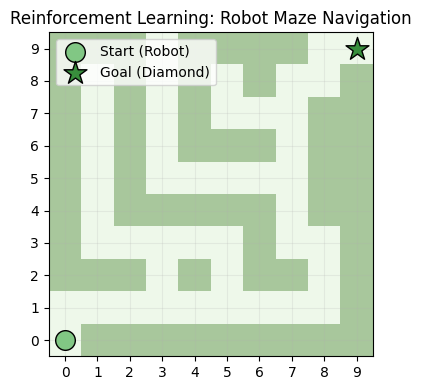

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0, 0)
goal = (9, 9)


num_episodes = 5000
alpha = 0.1
gamma = 0.9
epsilon = 0.5

reward_fire = -10
reward_goal = 50
reward_step = -1

actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

Q = np.zeros(maze.shape + (len(actions),))

cmap = ListedColormap(['#eef8ea', '#a8c79c'])

plt.figure(figsize=(4, 4))
plt.imshow(maze, cmap=cmap)
plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black',
            s=200, label='Start (Robot)', zorder=5)
plt.scatter(goal[1], goal[0], marker='*', color='#388e3c', edgecolors='black',
            s=300, label='Goal (Diamond)', zorder=5)
plt.title('Reinforcement Learning: Robot Maze Navigation')
plt.gca().invert_yaxis()
plt.xticks(range(maze.shape[1]))
plt.yticks(range(maze.shape[0]))
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


Value iteration converged in 26 iterations


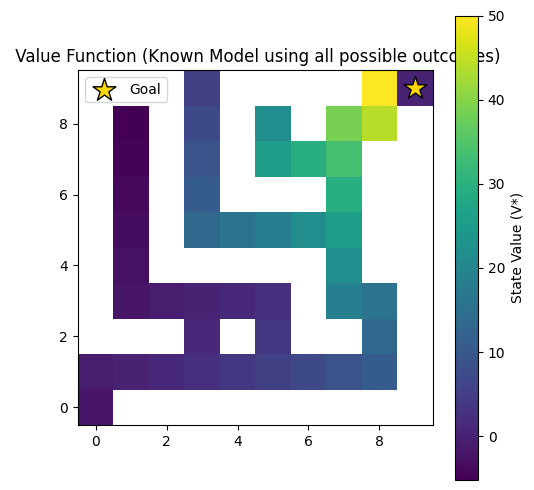

In [31]:
# Initialize state-value table (walls = NaN)
V = np.zeros_like(maze, dtype=float)
V[maze == 1] = np.nan  # walls are not valid states

theta = 1e-4  # convergence tolerance
gamma = 0.9
reward_goal = 50
reward_step = -1
reward_fire = -10

def value_iteration(V, gamma, max_iter=1000):
    for it in range(max_iter):
        delta = 0
        new_V = V.copy()
        for r in range(maze.shape[0]):
            for c in range(maze.shape[1]):
                if maze[r, c] == 1 or (r, c) == goal:
                    continue
                values = []
                for dr, dc in actions:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
                        if maze[nr, nc] == 1:
                            reward = reward_fire
                            val = reward + gamma * 0
                        elif (nr, nc) == goal:
                            reward = reward_goal
                            val = reward + gamma * 0
                        else:
                            reward = reward_step
                            val = reward + gamma * V[nr, nc]
                        values.append(val)
                if values:
                    new_V[r, c] = max(values)
                    delta = max(delta, abs(new_V[r, c] - V[r, c]))
        V = new_V
        if delta < theta:
            print(f"Value iteration converged in {it+1} iterations")
            break
    return V

V_opt = value_iteration(V, gamma)

# Visualize value function heatmap
plt.figure(figsize=(5,5))
plt.imshow(V_opt, cmap='viridis')
plt.colorbar(label='State Value (V*)')
plt.scatter(goal[1], goal[0], marker='*', s=300, color='gold', edgecolors='black', label='Goal')
plt.title(' Value Function (Known Model using all possible outcomes)')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()


| Aspect                       | **Unsupervised Learning**           | **Dynamic Programming**       | **Reinforcement Learning**               |
| ---------------------------- | ----------------------------------- | ----------------------------- | ---------------------------------------- |
| **Input**                    | Fixed data (no interaction)         | Known environment model       | Experience from environment              |
| **Objective**                | Find structure (clusters, patterns) | Compute optimal values/policy | Learn optimal policy via trial and error |
| **Knowledge of transitions** | Not applicable                      | Fully known                   | Unknown, learned through experience      |
| **Feedback**                 | None                                | Direct via known rewards      | Delayed, from environment                |
| **Example outcome**          | Clustered map regions               | Value map of optimal return   | Learned Q-table & optimal path           |
| **Computation type**         | Static analysis                     | Planning                      | Learning by interaction                  |


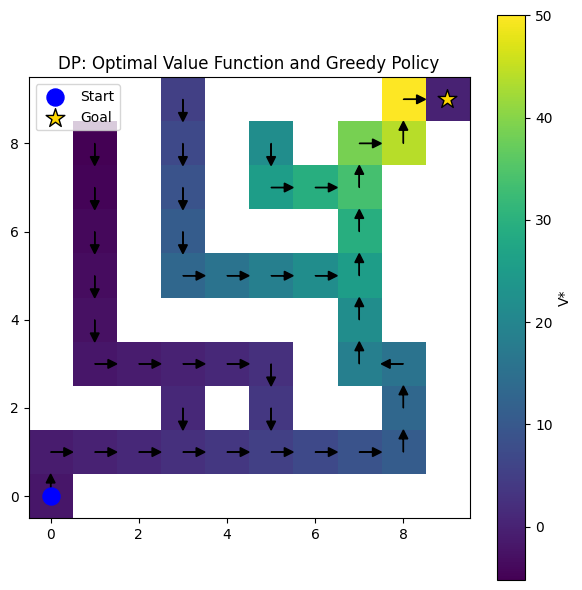

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- DP: Value Iteration (deterministic transitions)
gamma_dp = 0.9
theta = 1e-6

V = np.zeros_like(maze, dtype=float)
V[maze == 1] = np.nan  # mask walls

def dp_value_iteration(V, gamma=0.9, theta=1e-6):
    V = V.copy()
    while True:
        delta = 0.0
        for r in range(maze.shape[0]):
            for c in range(maze.shape[1]):
                if maze[r,c] == 1 or (r,c) == goal:
                    continue
                vals = []
                for (dr,dc) in actions:
                    nr, nc = r+dr, c+dc
                    if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
                        if maze[nr,nc] == 1:
                            vals.append(reward_fire + gamma * 0)
                        elif (nr,nc) == goal:
                            vals.append(reward_goal + gamma * 0)
                        else:
                            vals.append(reward_step + gamma * V[nr,nc])
                if vals:
                    newv = max(vals)
                    delta = max(delta, abs(newv - V[r,c] if not np.isnan(V[r,c]) else 0))
                    V[r,c] = newv
        if delta < theta:
            break
    return V

V_star = dp_value_iteration(V, gamma=gamma_dp, theta=theta)

# --- Greedy policy from V*
def dp_greedy_policy_from_V(V):
    P = np.full(maze.shape, -1, dtype=int)  # action index
    for r in range(maze.shape[0]):
        for c in range(maze.shape[1]):
            if maze[r,c] == 1 or (r,c) == goal:
                continue
            best_a, best_val = None, -1e18
            for a_idx,(dr,dc) in enumerate(actions):
                nr, nc = r+dr, c+dc
                if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
                    if maze[nr,nc] == 1:
                        val = reward_fire
                    elif (nr,nc) == goal:
                        val = reward_goal
                    else:
                        val = reward_step + gamma_dp * V[nr,nc]
                    if val > best_val:
                        best_val, best_a = val, a_idx
            P[r,c] = best_a
    return P

P_star = dp_greedy_policy_from_V(V_star)

# --- Visualize V* and arrows
plt.figure(figsize=(6,6))
plt.imshow(V_star, cmap='viridis')
plt.colorbar(label='V*')
for r in range(maze.shape[0]):
    for c in range(maze.shape[1]):
        if maze[r,c] == 0 and P_star[r,c] != -1:
            dr,dc = actions[P_star[r,c]]
            plt.arrow(c, r, 0.3*dc, 0.3*dr, head_width=0.2, head_length=0.2, fc='k', ec='k')
plt.scatter(start[1], start[0], c='blue', s=150, label='Start')
plt.scatter(goal[1], goal[0], c='gold', s=200, marker='*', label='Goal', edgecolors='k')
plt.title('DP: Optimal Value Function and Greedy Policy')
plt.gca().invert_yaxis(); plt.legend(); plt.tight_layout(); plt.show()


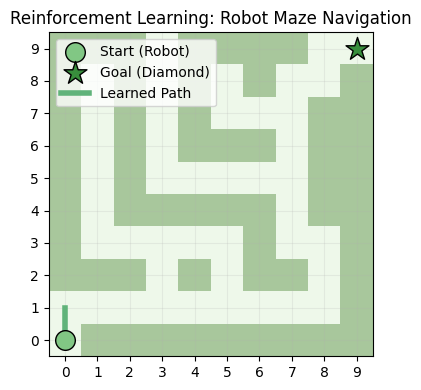

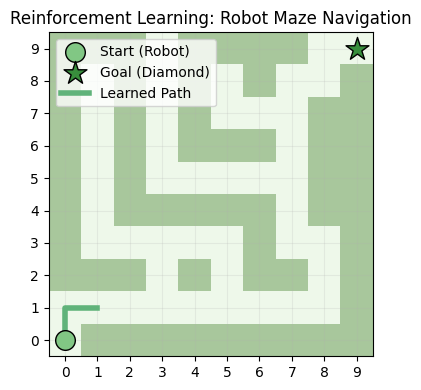

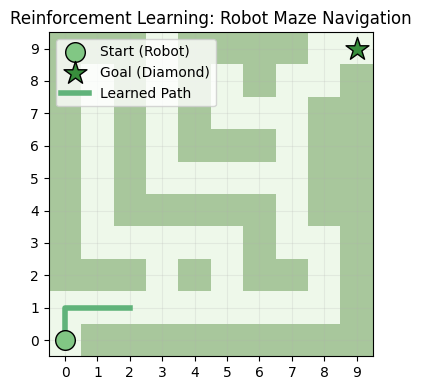

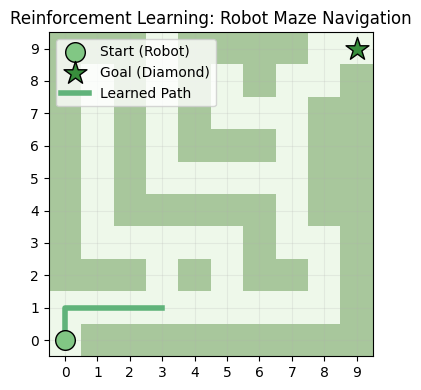

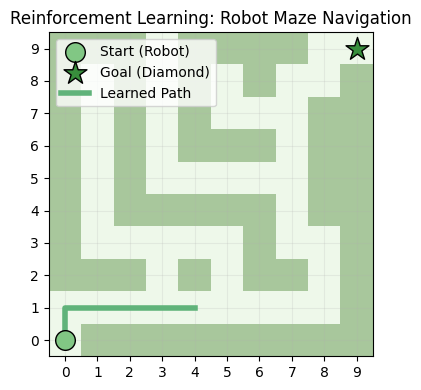

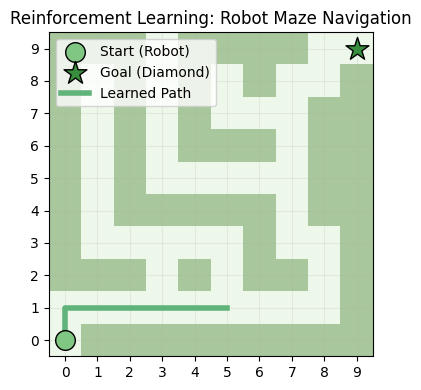

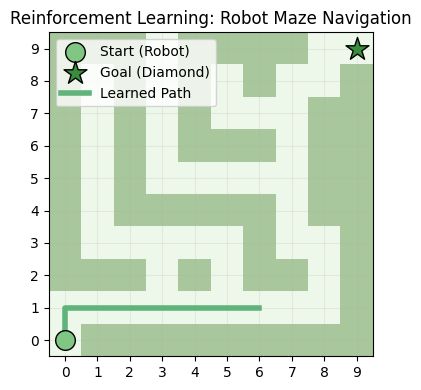

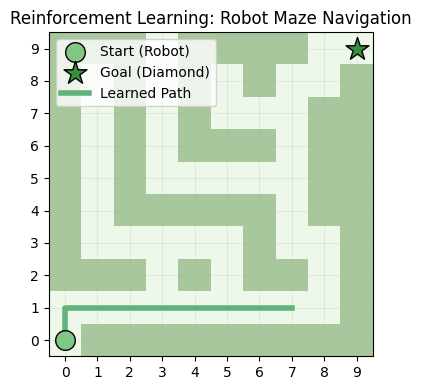

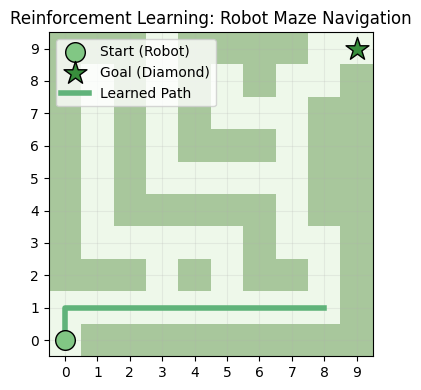

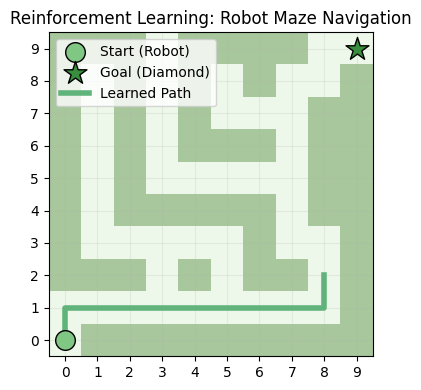

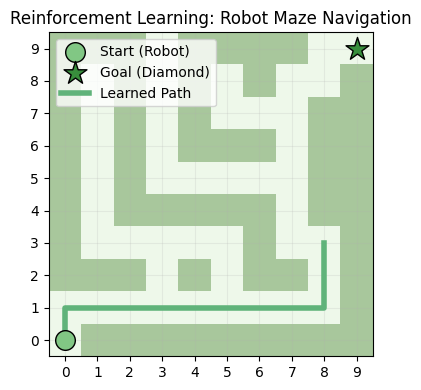

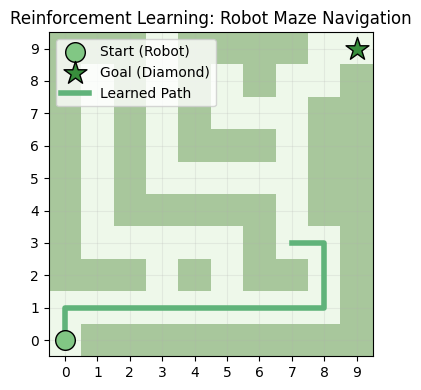

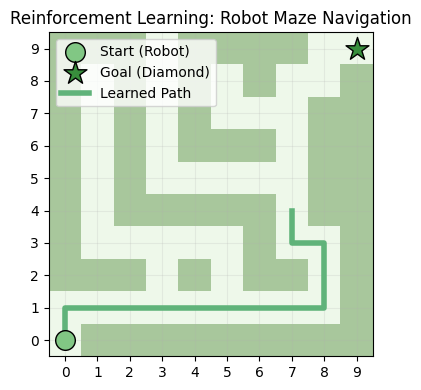

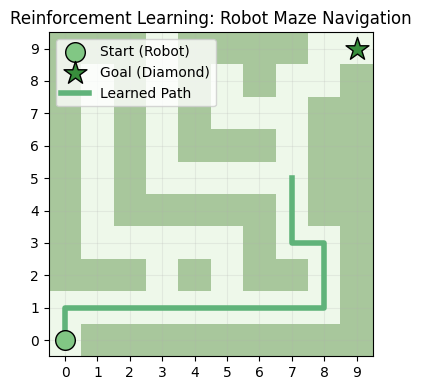

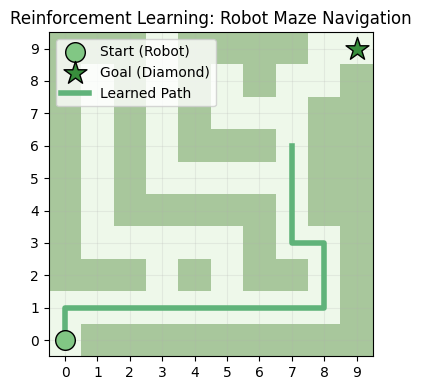

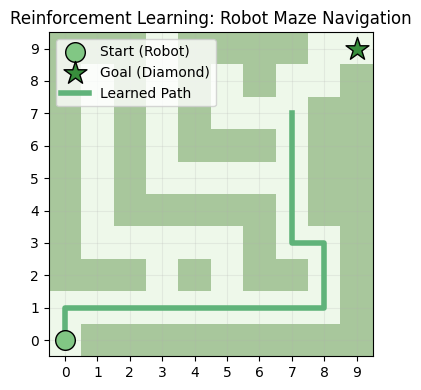

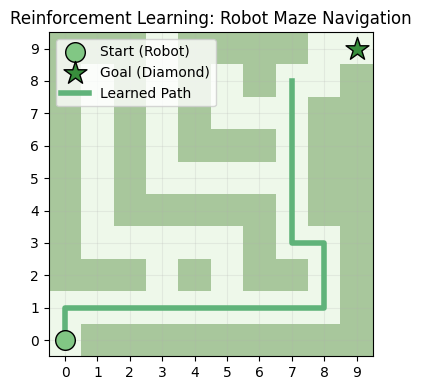

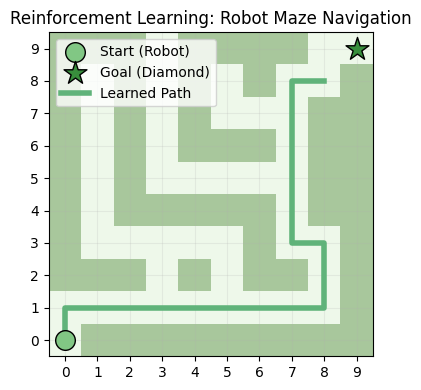

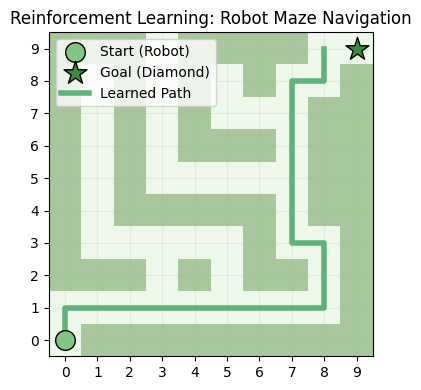

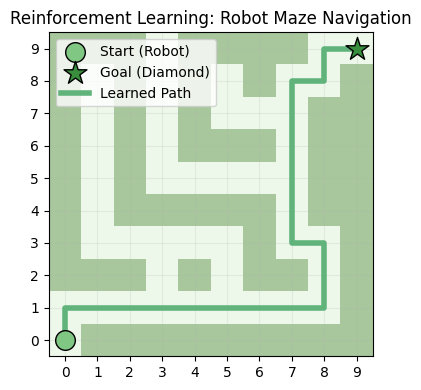

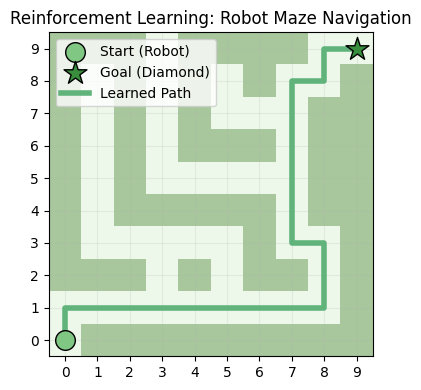

In [35]:

num_episodes = 5000 #100 #5000 10
alpha = 0.1
gamma = 0.9
epsilon = 0.5

reward_fire = -10
reward_goal = 50
reward_step = -1


def is_valid(pos):
    r, c = pos
    if r < 0 or r >= maze.shape[0]:
        return False
    if c < 0 or c >= maze.shape[1]:
        return False
    if maze[r, c] == 1:
        return False
    return True


def choose_action(state):
    if np.random.random() < epsilon:
        return np.random.randint(len(actions))
    else:
        return np.argmax(Q[state])


rewards_all_episodes = []


for episode in range(num_episodes):
    state = start
    total_rewards = 0
    done = False

    while not done:
        action_index = choose_action(state)
        action = actions[action_index]

        next_state = (state[0] + action[0], state[1] + action[1])

        if not is_valid(next_state):
            reward = reward_fire
            done = True
        elif next_state == goal:
            reward = reward_goal
            done = True
        else:
            reward = reward_step

        old_value = Q[state][action_index]
        next_max = np.max(Q[next_state]) if is_valid(next_state) else 0

        Q[state][action_index] = old_value + alpha * \
            (reward + gamma * next_max - old_value)

        state = next_state
        total_rewards += reward

    global epsilon
    epsilon = max(0.01, epsilon * 0.995)
    rewards_all_episodes.append(total_rewards)


def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    plt.figure(figsize=(4, 4))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black',
                s=200, label='Start (Robot)', zorder=5)
    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c', edgecolors='black',
                s=300, label='Goal (Diamond)', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4,
             label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Robot Maze Navigation')
    plt.gca().invert_yaxis()
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200):
    path = [start]
    state = start
    visited = set()

    for _ in range(max_steps):
        if state == goal:
            break
        visited.add(state)

        best_action = None
        best_value = -float('inf')

        for idx, move in enumerate(actions):
            next_state = (state[0] + move[0], state[1] + move[1])

            if (0 <= next_state[0] < maze.shape[0] and
                0 <= next_state[1] < maze.shape[1] and
                maze[next_state] == 0 and
                    next_state not in visited):

                if Q[state][idx] > best_value:

                    best_value = Q[state][idx]
                    best_action = idx

        if best_action is None:
            break

        move = actions[best_action]
        state = (state[0] + move[0], state[1] + move[1])
        path.append(state)
        plot_maze_with_path(path)

    return path


optimal_path = get_optimal_path(Q, start, goal, actions, maze)



plot_maze_with_path(optimal_path)